In [1]:
%matplotlib inline
from __future__ import division
import matplotlib
import numpy as np
from pylab import *
from mpl_toolkits.mplot3d import Axes3D
import h5py
import os
import re
matplotlib.rcParams.update({"axes.formatter.limits": (-4,4)})
plotStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0}
stepStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0,"where":"post"}
np.seterr(divide='ignore',invalid='ignore')
pass

### Execute with time limit.

In [26]:
%%bash
dirname=data/1
filename=${dirname}/first_order_reversible.lm
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} first_order_reversible.sbml
lm_setp ${filename} writeInterval=1e-3 maxTime=2e0
echo "Execute the following command in `pwd`:"
lmes -r 1-1000 -f ${filename} -gr 0 -c 5 > ${filename}.log
echo "Finished."

lm_sbml_import v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


Done.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urbana-Champaign.

Setting parameters in simulation file data/1/first_order_reversible.lm:
maxTime=2e0
writeInterval=1e-3
Done.
Execute the following command in /Users/eroberts/Work/Lab/Git/LatticeMicrobesES/regression/first_order_reversible:
Finished.


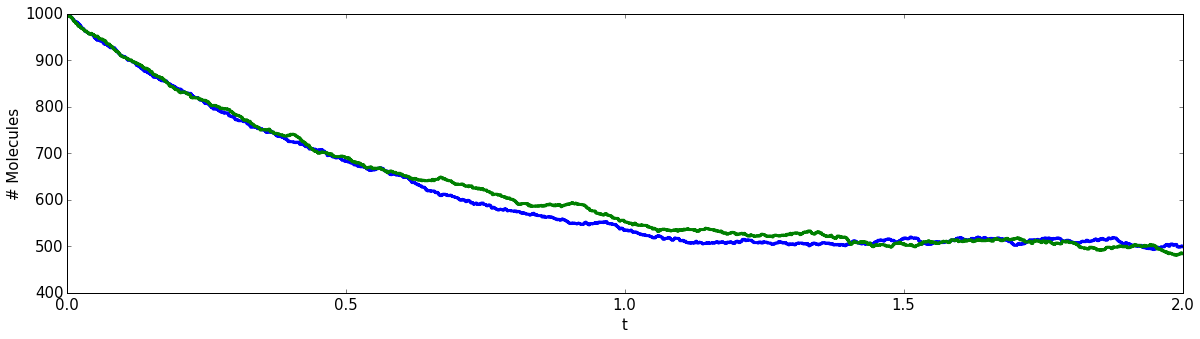

In [27]:
# Plot the time series for a single replicate.
dirname="data/1"
filename="%s/first_order_reversible.lm"%dirname
fp = h5py.File(filename, "r")
matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (20,5)})
for replicate in (1,2):
    counts=np.array(fp["/Simulations/%07d/SpeciesCounts"%replicate], dtype=double)
    times=np.array(fp["/Simulations/%07d/SpeciesCountTimes"%replicate], dtype=double)
    step(times,counts[:,0], **stepStyles)
xlabel('t'); ylabel('# Molecules')
pass

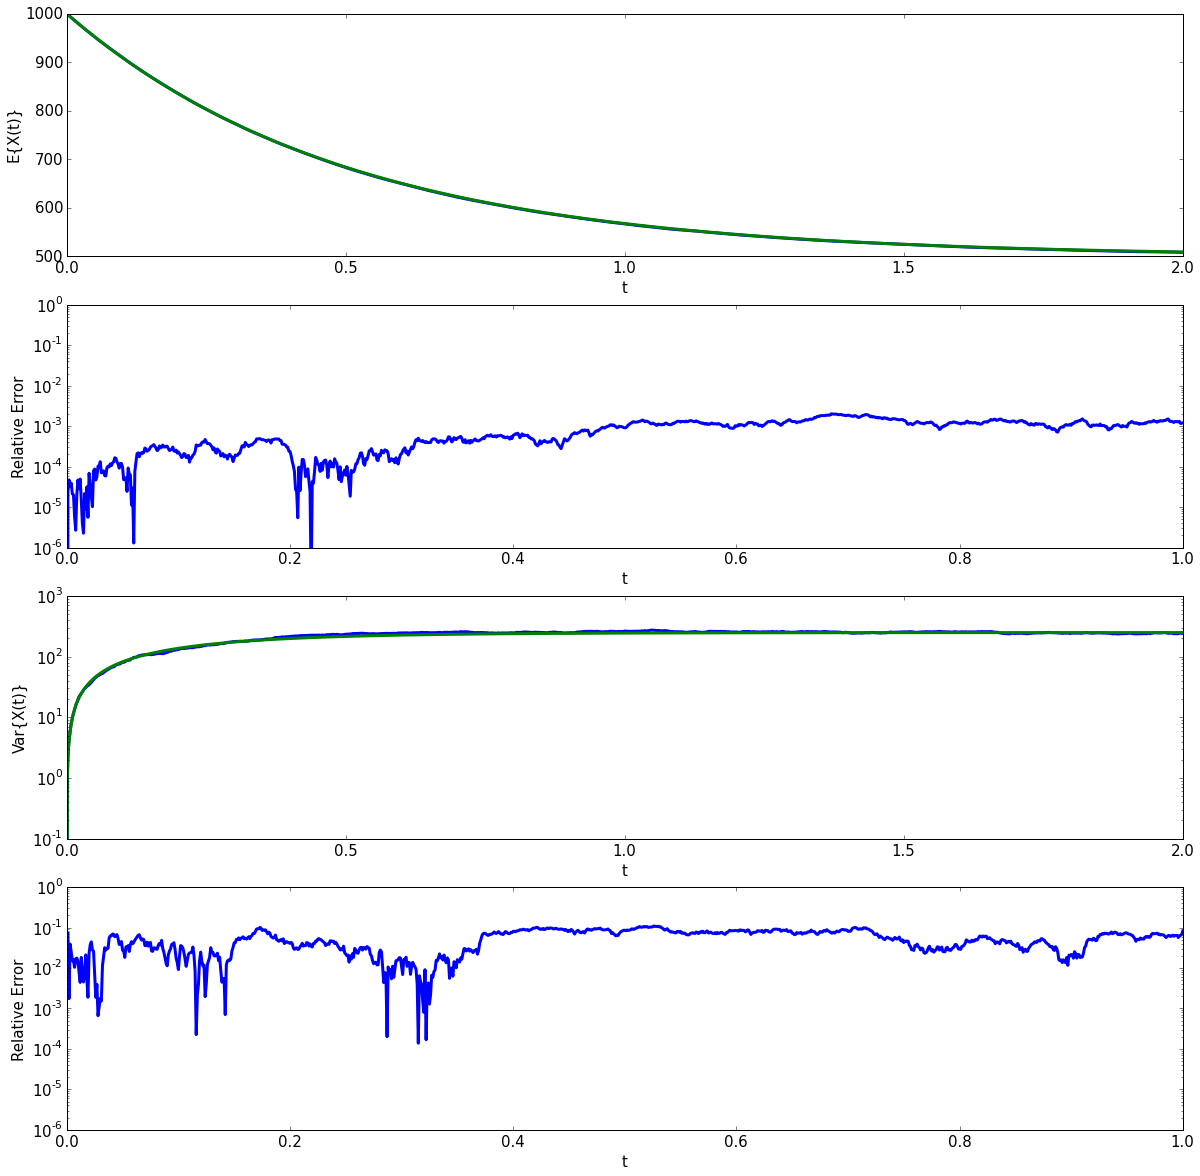

In [37]:
# Plot the accuracy of the mean and variance.
dirname="data/1"
filename="%s/first_order_reversible.lm"%dirname
fp = h5py.File(filename, "r")
replicates=fp["/Simulations"].keys()
k=0
mSim=None
vSim=None
times=None
for replicate in replicates:
    if times is None:
        times = np.array(fp["/Simulations/%s/SpeciesCountTimes"%replicate], dtype=double)
    counts = np.array(fp["/Simulations/%s/SpeciesCounts"%replicate], dtype=double)
    if mSim is None:
        k += 1
        mSim = counts
        vSim = np.zeros(counts.shape, dtype=double)
    else:
        k += 1
        mSim = mSim + (counts-mSim)/k
        vSim = vSim + (counts-mSim)*(counts-mSim)
vSim /= float((k-1))

A0=mSim[0,0]
k1=1.0
k2=1.0
k=k1+k2
lam=k1/k2
ome=lam*exp(-k*times)+1
mTheory=(A0/k)*(k1*exp(-k*times)+k2)
vTheory=((A0*ome)/(1+lam))*(1-(ome/(1+lam)))


matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (20,20)})
ax=plt.subplot(4,1,1)
plt.plot(times,mSim[:,0], **plotStyles)
plt.plot(times,mTheory, **plotStyles)
ax.set_yscale('linear'); xlabel('t'); ylabel('E{X(t)}')

ax=plt.subplot(4,1,2)
plt.plot(times,abs(mSim[:,0]-mTheory)/mTheory, **plotStyles)
ax.set_yscale('log'); xlim([0,1]); ylim([1e-6,1e0]); xlabel('t'); ylabel('Relative Error')

ax=plt.subplot(4,1,3)
plt.plot(times,vSim[:,0], **plotStyles)
plt.plot(times,vTheory, **plotStyles)
ax.set_yscale('log'); xlabel('t'); ylabel('Var{X(t)}')

ax=plt.subplot(4,1,4)
plt.plot(times,abs(vSim[:,0]-vTheory)/vTheory, **plotStyles)
ax.set_yscale('log'); xlim([0,1]); ylim([1e-6,1e-0]); xlabel('t'); ylabel('Relative Error')
pass